# Healthcare Patient Analysis & Insights

## 1. Project Overview

This project analyzes healthcare patient data using Python to
understand patient demographics, medical conditions, hospital
admissions, billing, and other healthcare-related patterns.

The project covers data understanding, data cleaning,
exploratory data analysis, visualization, and statistical analysis.

## 2. Import Libraries

The required Python libraries are imported to perform data manipulation, analysis, and visualization.

- **Pandas** – used for data loading, cleaning, manipulation, and analysis.
- **NumPy** – used for numerical operations.
- **Matplotlib** – used to create visualizations and charts.
- **Seaborn** – used to create statistical and informative visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is working!")

Environment is working!


In [2]:
df = pd.read_csv("../data/healthcare_dataset.csv")

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.shape

(55500, 15)

In [5]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

## 3.Initial Dataset Observations

- The dataset contains 55,500 patient records and 15 columns.
- All columns contain 55,500 non-null values, indicating no missing values at this stage.
- The dataset contains 3 numeric columns: Age, Billing Amount, and Room Number.
- The remaining 12 columns are stored as string values.
- Date of Admission and Discharge Date are currently stored as strings and may need to be converted to datetime format.
- Initial inspection also suggests potential text-format inconsistencies in patient names that should be investigated during data cleaning.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB



## 4. Data Understanding

The dataset was examined to understand its structure, data types, dimensions, and basic statistical characteristics.

The initial analysis included:

- Checking the number of rows and columns.
- Reviewing column names and data types.
- Inspecting the first few records.
- Checking for missing values.
- Identifying duplicate records.
- Examining descriptive statistics for numerical variables.
- Reviewing categorical variables such as gender, medical condition, admission type, and test results.

This step helped identify potential data quality issues that needed to be addressed during the cleaning process.

In [7]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


## 5. Initial Data Profiling Findings

The initial profiling of the dataset revealed the following:

- The dataset contains 55,500 patient records and 15 columns.
- There are currently no missing values across the dataset.
- Three columns are numeric: Age, Billing Amount, and Room Number.
- Date of Admission and Discharge Date are currently stored as strings.
- Patient names show inconsistent capitalization and should be investigated during data cleaning.
- Age ranges from 13 to 89 years, with an average age of approximately 51.5 years.
- Billing Amount ranges from -2,008.49 to 52,764.28. The presence of a negative billing amount requires further investigation before deciding how to handle these records.

In [8]:
df[df["Billing Amount"]<0].shape

(108, 15)

In [ ]:
neg_billing=df[df["Billing Amount"]<0]
neg_billing.shape[0]

108

In [10]:
neg_billing.shape[0]/df.shape[0]*100


0.19459459459459458

In [11]:
neg_billing.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal


In [12]:
neg_billing["Medical Condition"].value_counts()


Medical Condition
Hypertension    21
Diabetes        20
Cancer          19
Obesity         19
Asthma          18
Arthritis       11
Name: count, dtype: int64

In [13]:
neg_billing["Admission Type"].value_counts()

Admission Type
Urgent       38
Elective     37
Emergency    33
Name: count, dtype: int64

In [14]:
duplicate=df.duplicated().sum()
df.duplicated().sum()

np.int64(534)

In [15]:
duplicate/len(df)*100

np.float64(0.9621621621621621)

In [16]:
df[df.duplicated(keep=False)].head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
64,Nancy glOVeR,58,Male,A-,Hypertension,2020-05-08,Jennifer Larson,"Khan, and Rodriguez Fischer",Medicare,19183.168885,378,Emergency,2020-06-01,Aspirin,Abnormal
107,DAVid higgInS,49,Female,B-,Arthritis,2021-03-05,Erin Henderson MD,"Evans and Hall Schneider,",Medicare,24948.477824,361,Emergency,2021-03-20,Penicillin,Abnormal
148,RoBErt hIGGInS,42,Male,AB-,Asthma,2021-05-06,Scott Davis,"and Ford Lee, Rodriguez",Medicare,13355.782085,451,Elective,2021-05-29,Ibuprofen,Inconclusive
154,kevIn HiCKs,66,Male,AB+,Arthritis,2021-06-23,Kelly Murphy,Robinson Inc,Medicare,1897.891727,196,Elective,2021-07-09,Ibuprofen,Abnormal
159,miCHAeL TayloR,29,Male,O-,Asthma,2020-02-27,Erica Mccormick,Donaldson-Frey,Medicare,41939.119937,453,Elective,2020-03-26,Ibuprofen,Normal


In [17]:
df[df.eq(df.loc[621]).all(axis=1)]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
621,JesSIcA caRtER,51,Female,A-,Obesity,2019-12-08,Sarah Ibarra,Anderson Group,Cigna,32006.031566,200,Urgent,2020-01-05,Penicillin,Normal
55383,JesSIcA caRtER,51,Female,A-,Obesity,2019-12-08,Sarah Ibarra,Anderson Group,Cigna,32006.031566,200,Urgent,2020-01-05,Penicillin,Normal


In [18]:
df_clean=df.copy()

In [19]:
df_clean=df_clean.drop_duplicates()
df_clean.shape

(54966, 15)

## 6. Data Cleaning

The dataset was cleaned to improve data quality and ensure that the data was suitable for further analysis.

### Cleaning Steps Performed

- Created a separate `df_clean` DataFrame to preserve the original dataset.
- Identified and removed duplicate records.
- Identified records with negative billing amounts.
- Removed invalid negative billing records because billing amounts should not be negative for this analysis.
- Checked for missing values.
- Converted admission and discharge dates from text format to datetime format.

After the initial cleaning process, the dataset contains **54,860 records and 15 columns**.

The original dataset contained 55,500 records.

In [20]:
df_clean["Date of Admission"]=pd.to_datetime(df_clean["Date of Admission"])
df_clean["Discharge Date"]=pd.to_datetime(df_clean["Discharge Date"])

In [21]:
df_clean=df_clean[df_clean["Billing Amount"]>0]


### Standardizing Patient Names

The `Name` column contained inconsistent capitalization, with some patient names written using a mixture of uppercase and lowercase letters.

To improve consistency and readability, patient names were standardized using title case.

For example:

- `DaNnY sMitH` → `Danny Smith`
- `andrEw waTtS` → `Andrew Watts`
- `adrIENNE bEll` → `Adrienne Bell`

This standardization improves data presentation and ensures consistent formatting for future analysis and reporting.

In [22]:
df_clean["Name"]=df_clean["Name"].str.title()
df_clean["Name"].str.title()

0            Bobby Jackson
1             Leslie Terry
2              Danny Smith
3             Andrew Watts
4            Adrienne Bell
               ...        
55495    Elizabeth Jackson
55496           Kyle Perez
55497         Heather Wang
55498       Jennifer Jones
55499         James Garcia
Name: Name, Length: 54860, dtype: str

In [23]:
df_clean.duplicated().sum()

np.int64(0)

### Duplicate Validation

After removing duplicate records, the cleaned dataset was checked again using `duplicated()`.

The validation returned **0 duplicate records**, confirming that all complete duplicate rows were successfully removed.

In [24]:
df_clean[df_clean["Billing Amount"]<0].shape

(0, 15)

### Negative Billing Validation

After removing records with negative billing amounts, the cleaned dataset was checked again.

The validation returned **0 records with negative billing amounts**, confirming that the invalid billing values were successfully removed.

In [25]:
df_clean.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Missing Value Validation

The cleaned dataset was checked for missing values using `isnull().sum()`.

The validation returned **0 missing values**, confirming that no null values are present in the cleaned dataset.

In [26]:
df_clean["Date of Admission"]
df_clean["Discharge Date"]

0       2024-02-02
1       2019-08-26
2       2022-10-07
3       2020-12-18
4       2022-10-09
           ...    
55495   2020-09-15
55496   2020-02-01
55497   2020-08-10
55498   2019-05-31
55499   2024-04-29
Name: Discharge Date, Length: 54860, dtype: datetime64[us]

### Date Validation

The admission and discharge date columns were converted from text to datetime format.

The dataset was then checked for records where the discharge date occurred before the admission date.

The validation returned **0 records**, confirming that the admission and discharge dates are logically consistent.

In [27]:
df_clean[df_clean["Discharge Date"] < df_clean["Date of Admission"]].shape

(0, 15)

### Creating Length of Stay

A new `Length of Stay` column was created by calculating the number of days between the patient's admission date and discharge date.

This derived feature will be useful for analyzing hospital stay patterns, average length of stay, and relationships between length of stay and other healthcare factors.

In [28]:
df_clean["Length of stay"]=(df_clean["Discharge Date"]-df_clean["Date of Admission"]).dt.days
(df_clean["Discharge Date"]-df_clean["Date of Admission"]).dt.days

0         2
1         6
2        15
3        30
4        20
         ..
55495    30
55496     9
55497    28
55498     6
55499    27
Length: 54860, dtype: int64

### Length of Stay Validation

The newly created `Length of Stay` feature was validated by checking its minimum value.

The minimum length of stay is **1 day**, confirming that there are no records with a negative or zero hospital stay.

In [29]:
df_clean["Length of stay"].min()

np.int64(1)

In [30]:
df_clean.dtypes

Name                             str
Age                            int64
Gender                           str
Blood Type                       str
Medical Condition                str
Date of Admission     datetime64[us]
Doctor                           str
Hospital                         str
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Length of stay                 int64
dtype: object

## 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand patterns, distributions, and relationships within the cleaned healthcare dataset.

The analysis focuses on patient demographics, medical conditions, hospital admissions, billing, medications, test results, and length of stay.

The following questions will be explored:

- What is the distribution of patients by age and gender?
- Which medical conditions are most common?
- What are the most common admission types?
- Which insurance providers are most frequently used?
- What is the average billing amount?
- What is the average length of hospital stay?
- Which medical conditions have the highest average billing?
- How do admission types vary across patients?
- What patterns can be observed in test results and medications?

### 7.1 Patient Demographics

The first stage of the exploratory analysis focuses on patient demographics.

Age and gender distributions are analyzed to understand the overall demographic characteristics of the patients in the dataset.

In [31]:
df_clean["Age"].describe()

count    54860.000000
mean        51.533850
std         19.605295
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

In [32]:
df_clean["Age"].mean()

np.float64(51.53384979948961)

In [33]:
df_clean["Age"].median()

np.float64(52.0)

In [34]:
df_clean["Gender"].value_counts()

Gender
Male      27449
Female    27411
Name: count, dtype: int64

### 7.2 Medical Conditions

This analysis examines the distribution of medical conditions among patients to identify the most and least common conditions in the dataset.

In [35]:
df_clean["Medical Condition"].value_counts(normalize=True)*100

Medical Condition
Arthritis       16.782720
Diabetes        16.764491
Hypertension    16.644185
Obesity         16.636894
Cancer          16.625957
Asthma          16.545753
Name: proportion, dtype: float64

### 7.3 Admission Analysis

This analysis examines the different types of hospital admissions in the dataset.

The objective is to understand the distribution of Emergency, Urgent, and Elective admissions and identify the most common admission type.

In [36]:
df_clean["Admission Type"].value_counts(normalize=True)*100

Admission Type
Elective     33.607364
Urgent       33.454247
Emergency    32.938389
Name: proportion, dtype: float64

### 7.4 Billing Analysis

This analysis examines the billing amounts associated with patient hospitalizations.

The objective is to understand the overall billing distribution and identify the average, median, minimum, and maximum billing amounts.

In [37]:
df_clean["Billing Amount"].describe()

count    54860.000000
mean     25594.633637
std      14175.867041
min          9.238787
25%      13299.747940
50%      25593.873000
75%      37847.066671
max      52764.276736
Name: Billing Amount, dtype: float64

In [38]:
df_clean["Billing Amount"].mean()

np.float64(25594.633636750525)

In [39]:
df_clean.groupby("Medical Condition")["Billing Amount"].mean().sort_values(ascending=False)

Medical Condition
Obesity         25859.215373
Diabetes        25714.326349
Asthma          25685.385020
Hypertension    25559.844868
Arthritis       25542.898356
Cancer          25205.924207
Name: Billing Amount, dtype: float64

### 7.5 Length of Stay Analysis

This analysis examines the duration of patients' hospital stays.

The objective is to understand the typical length of hospitalization and identify whether some patients have unusually long stays.

In [40]:
df_clean["Length of stay"].describe()

count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of stay, dtype: float64

### 7.6 Medication & Test Results Analysis

This analysis examines the medications prescribed to patients and the distribution of their test results.

The objective is to identify the most commonly prescribed medications and understand the overall distribution of Normal, Abnormal, and Inconclusive test results.

In [41]:
df_clean["Medication"].value_counts()

Medication
Lipitor        11018
Ibuprofen      11002
Aspirin        10963
Paracetamol    10945
Penicillin     10932
Name: count, dtype: int64

In [42]:
df_clean["Test Results"].value_counts(normalize=True)*100

Test Results
Abnormal        33.538097
Normal          33.361283
Inconclusive    33.100620
Name: proportion, dtype: float64

### 8.1 Age Distribution

The age distribution of patients is visualized to understand the demographic structure of the dataset and identify the age ranges with the highest number of patients.

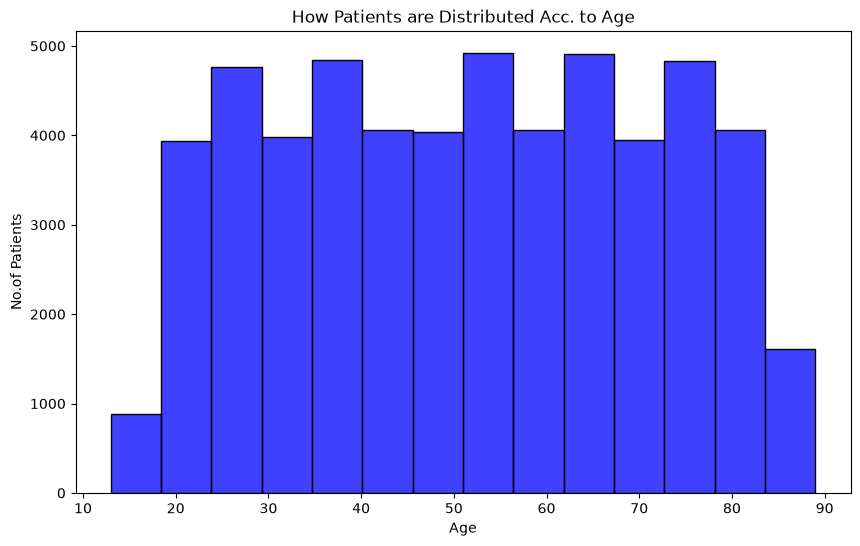

In [55]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_clean, x="Age", bins=14,color="blue")
plt.title("How Patients are Distributed Acc. to Age")
plt.xlabel("Age")
plt.ylabel("No.of Patients")
plt.savefig("../images/age_distribution.png", bbox_inches="tight")
plt.show()

### 8.2 Gender Distribution

A bar chart is used to visualize the distribution of patients by gender and compare the number of male and female patients.


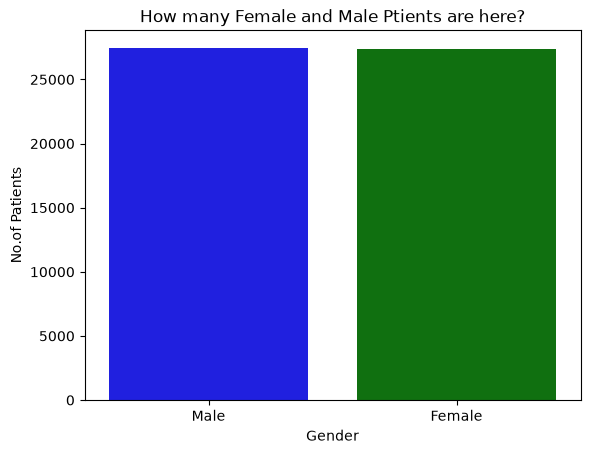

In [54]:
plt.Figure(figsize=(9,5))
sns.countplot(data=df_clean,x="Gender",hue="Gender",palette=("blue","green"),legend=False)
plt.title("How many Female and Male Ptients are here?")
plt.xlabel("Gender")
plt.ylabel("No.of Patients")
plt.savefig("../images/gender distribution.png", bbox_inches="tight")
plt.show()

## 8.3. Distribution of Admission Types

This visualization shows the distribution of patients across different admission types. It helps identify whether patients were admitted through elective, urgent, or emergency procedures and whether one admission type is more common than others.

In [45]:
admission_counts = df_clean['Admission Type'].value_counts()

admission_counts

Admission Type
Elective     18437
Urgent       18353
Emergency    18070
Name: count, dtype: int64

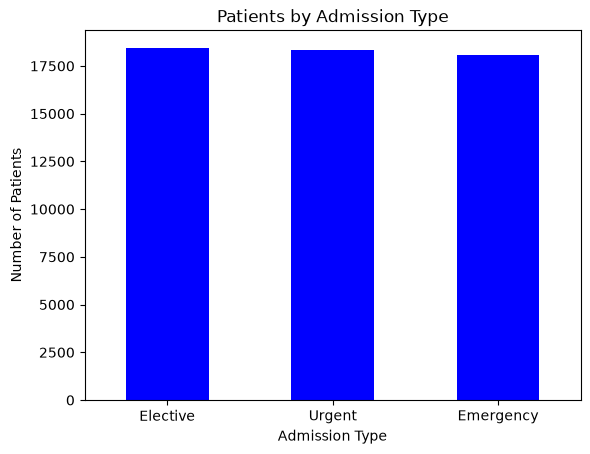

In [53]:
admission_counts.plot(kind='bar', color='blue')

plt.title('Patients by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.savefig("../images/patients_by_admission_type.png", bbox_inches="tight")
plt.show()


## 8.4. Distribution of Medical Conditions

This visualization shows the number of patients with each medical condition. It helps identify the most common health conditions represented in the dataset.

In [47]:
condition_counts = df_clean['Medical Condition'].value_counts()

condition_counts


Medical Condition
Arthritis       9207
Diabetes        9197
Hypertension    9131
Obesity         9127
Cancer          9121
Asthma          9077
Name: count, dtype: int64

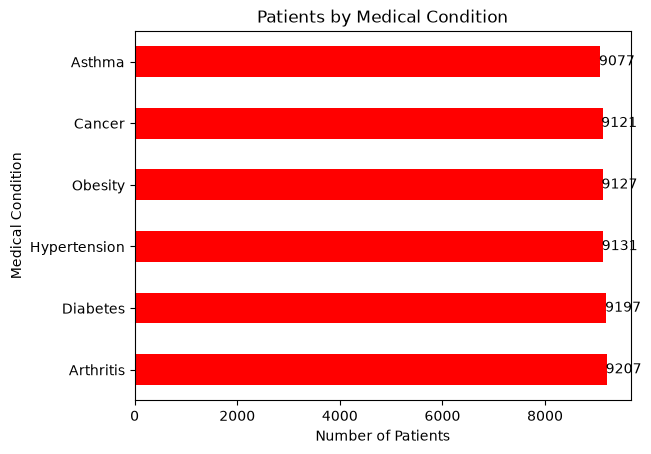

In [52]:
condition_counts.plot(kind='barh', color='red')

plt.title('Patients by Medical Condition')
plt.xlabel('Number of Patients')
plt.ylabel('Medical Condition')
plt.bar_label(plt.gca().containers[0], fmt='%d', padding=-1)
plt.savefig("../images/medical_conditions.png", bbox_inches="tight")
plt.show()

## 8.5 Average Billing Amount by Medical Condition

To understand the financial impact of different medical conditions, I calculated the average billing amount for each medical condition.

This analysis helps identify which medical conditions are associated with higher or lower average healthcare costs.

A horizontal bar chart was used to make the comparison between medical conditions easier to read.

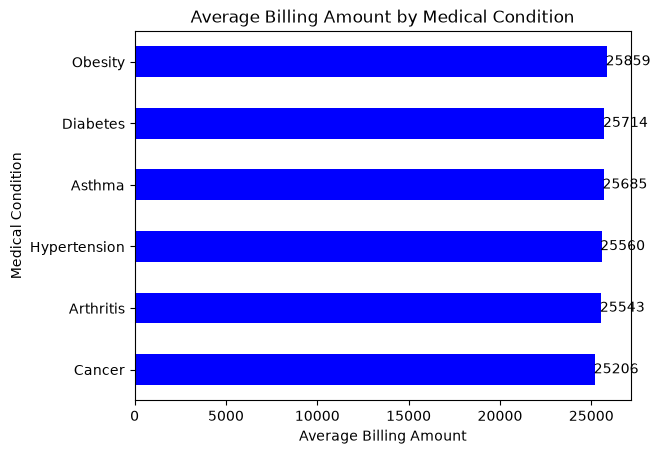

In [ ]:
billing_by_condition = df_clean.groupby("Medical Condition")["Billing Amount"].mean().sort_values()

billing_by_condition.plot(kind="barh", color="blue")

plt.title("Average Billing Amount by Medical Condition")
plt.xlabel("Average Billing Amount")
plt.ylabel("Medical Condition")

plt.bar_label(plt.gca().containers[0], fmt="%.0f", padding=-1)
plt.savefig("../images/avg_billing_amount"".png", bbox_inches="tight")

plt.show()

## 8.6 Average Length of Stay by Admission Type

To analyze hospital stay patterns, I calculated the average length of stay for each admission type.

This analysis helps identify whether Emergency, Urgent, or Elective admissions are associated with longer hospital stays.

A bar chart was used to compare the average length of stay across admission types.

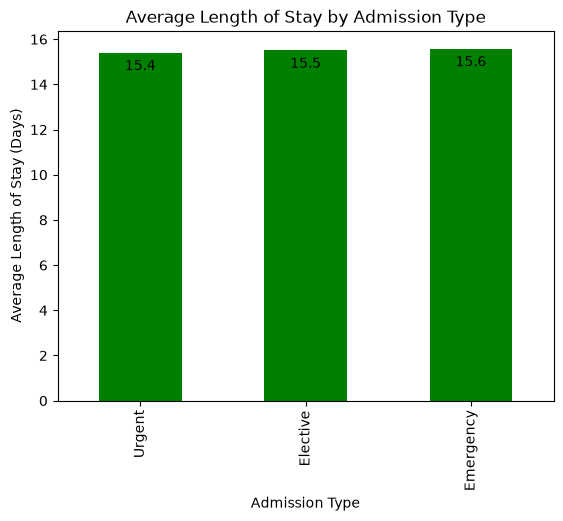

In [57]:
stay_by_admission=df_clean.groupby("Admission Type")["Length of stay"].mean().sort_values()
stay_by_admission.plot(kind="bar", color="green")

plt.title("Average Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Length of Stay (Days)")

plt.bar_label(plt.gca().containers[0], fmt="%.1f", padding=-15)
plt.savefig("../images/avg_length_of_stays.png", bbox_inches="tight")
plt.show()

## 8.7 Distribution of Billing Amount

To understand the overall distribution of healthcare costs, I analyzed the billing amounts for all patients.

A histogram was used to show how frequently different billing amount ranges occur.

This visualization helps identify the typical billing range and whether there are unusually high or low billing amounts.

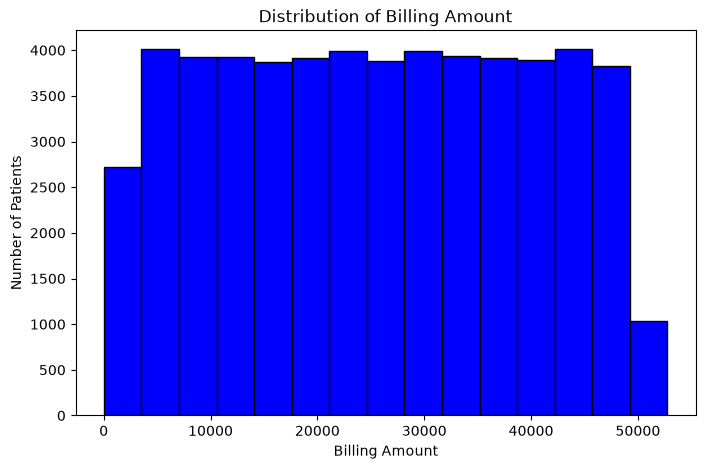

In [58]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["Billing Amount"], bins=15, color="blue", edgecolor="black")

plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount")
plt.ylabel("Number of Patients")
plt.savefig("../images/distribution_of_billing_amount.png", bbox_inches="tight")

plt.show()

# 9. Key Findings

The exploratory analysis of the healthcare dataset revealed several important patterns related to patient demographics, medical conditions, hospital utilization, and billing.

### Patient Demographics

The gender distribution is highly balanced, with male and female patients representing approximately half of the dataset each. This indicates that there is no substantial gender imbalance in the patient population.

The age analysis shows that older patients represent a larger proportion of the dataset. Patients aged 51 and above account for more than half of the patient population, indicating that the dataset is more concentrated among middle-aged and older adults.

### Medical Conditions

The distribution of medical conditions is remarkably balanced. Arthritis has the highest number of patients at 9,207, while Asthma has the lowest at 9,077. The difference of only 130 patients suggests that no single medical condition dominates the dataset.

### Healthcare Costs

Average billing amounts are also relatively consistent across medical conditions. Obesity has the highest average billing amount at 25,859, while Cancer has the lowest at 25,206. The relatively small difference of 653 between the highest and lowest averages suggests that medical condition has limited influence on average billing amounts within this dataset.

The billing distribution further shows that patient billing amounts are spread across a broad range of approximately 0 to 52,000, with most billing ranges containing a similar number of patients. This indicates that healthcare costs are not concentrated within a single billing range.

### Hospital Stay

Average length of stay varies very little by admission type. Emergency admissions have the highest average stay at 15.6 days, followed by Elective admissions at 15.5 days and Urgent admissions at 15.4 days. The difference of only 0.2 days indicates that admission type has minimal influence on average hospital stay in this dataset.

### Overall Finding

Overall, the analysis shows a relatively balanced patient population across gender and medical conditions, while age, billing amounts, and hospital stays provide more meaningful variation. The results also suggest that neither medical condition nor admission type creates a substantial difference in average billing or length of stay within this dataset.

## 10. Recommendations

Based on the analysis and visualizations, the following recommendations can be made:

1. **Prioritize chronic condition management:** Arthritis (9,207), Diabetes (9,197), and Hypertension (9,131) were among the most frequently recorded medical conditions. Healthcare providers can prioritize monitoring and preventive-care strategies for patients with these conditions.

2. **Maintain balanced attention across medical conditions:** The distribution of medical conditions was relatively even, indicating that no single condition overwhelmingly dominated the dataset. Healthcare resources should therefore be planned across multiple conditions rather than focusing on only one disease category.

3. **Focus on older patient groups:** The analysis showed that patients aged 51 and above represented approximately 54.02% of the dataset. Healthcare organizations should consider strengthening services and monitoring strategies that support the needs of older patients.

4. **Review billing patterns by medical condition:** Obesity had the highest average billing amount at approximately 25,859, while Cancer had the lowest at approximately 25,206. Although the difference was relatively small, billing patterns by condition should be monitored to identify potential differences in treatment costs and resource utilization.

5. **Monitor hospital stay duration:** Average length of stay was very similar across admission types, with Emergency admissions at approximately 15.6 days, Elective admissions at 15.5 days, and Urgent admissions at 15.4 days. This suggests that admission type alone did not create a major difference in average stay duration in this dataset.

6. **Use data-driven monitoring for healthcare planning:** The findings from patient demographics, medical conditions, billing, and length of stay can be combined to support better resource planning, patient management, and operational decision-making.

Overall, the analysis demonstrates how healthcare data can be used to identify patient patterns, understand resource utilization, and support evidence-based decision-making.
